# 1.라이브러리 및 데이터 불러오기

In [1]:
from sklearn.datasets import load_iris

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
iris_data = load_iris()
feature_names = ['sepal_length','sepal_width','petal_length','petal_width']

iris_df = pd.DataFrame(data=iris_data.data, columns=feature_names)
iris_df['target'] = iris_data.target

# 2.GMM
- KMeans와 유사한 군집화 알고리즘이지만, 더 유연하고 강력한 군집화 모델
- GMM은 각 군집이 가우시안 분포를 따른다고 가정한다.
    - 예를 들어, 데이터 포인트 (x)가 군집 A에 속할 확률이 70%, 군집 B에 속할 확률이 30%일 수 있다.


In [9]:
from sklearn.mixture import GaussianMixture

In [10]:
gmm = GaussianMixture(n_components=3, random_state=1)
gmm.fit(iris_data.data)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",1


In [11]:
gmm_cluster_labels = gmm.predict(iris_data.data)

In [12]:
iris_df['gmm_cluster'] = gmm_cluster_labels
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,gmm_cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1


In [13]:
from sklearn.metrics import silhouette_samples, silhouette_score

In [14]:
# iris의 모든 개별 데이터에 실루엣 계수 구하기
score_sample = silhouette_samples(iris_data.data, iris_df['gmm_cluster'])

In [15]:
iris_df['gmm_silhouette_coef'] = score_sample
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,gmm_cluster,gmm_silhouette_coef
0,5.1,3.5,1.4,0.2,0,1,0.842852
1,4.9,3.0,1.4,0.2,0,1,0.802692
2,4.7,3.2,1.3,0.2,0,1,0.818240
3,4.6,3.1,1.5,0.2,0,1,0.791922
4,5.0,3.6,1.4,0.2,0,1,0.839200


In [16]:
# 모든 데이터의 평균 실루엣 계수값
gmm_avg_score = silhouette_score(iris_data.data, iris_df['gmm_cluster'])
gmm_avg_score

0.5011761635067206

# 3.KMeans

In [17]:
from sklearn.cluster import KMeans

In [18]:
kmeans = KMeans(n_clusters=3,
                init='k-means++',
                max_iter=300,
                random_state=1)

In [19]:
kmeans.fit(iris_data.data)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [21]:
iris_df['kmeans_cluster'] = kmeans.labels_
iris_df

,sepal_length,sepal_width,petal_length,petal_width,target,gmm_cluster,gmm_silhouette_coef,kmeans_cluster
0,5.1,3.5,1.4,0.2,0,1,0.842852,1
1,4.9,3.0,1.4,0.2,0,1,0.802692,1
2,4.7,3.2,1.3,0.2,0,1,0.818240,1
3,4.6,3.1,1.5,0.2,0,1,0.791922,1
4,5.0,3.6,1.4,0.2,0,1,0.839200,1
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,2,0.447026,2
146,6.3,2.5,5.0,1.9,2,2,0.180213,0
147,6.5,3.0,5.2,2.0,2,2,0.410094,2
148,6.2,3.4,5.4,2.3,2,2,0.413837,2


In [ ]:
# 모든 개별 데이터에 실루엣 계수 구하기
score_sample = silhouette_samples(iris_data.data, iris_df['kmeans_cluster'])

In [22]:
# 데이터프레임에 kmeans_silhouette_coef 컬럼에 실루엣 계수 넣기
iris_df['kmeans_silhouette_coef'] = score_sample
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,gmm_cluster,gmm_silhouette_coef,kmeans_cluster,kmeans_silhouette_coef
0,5.1,3.5,1.4,0.2,0,1,0.842852,1,0.842852
1,4.9,3.0,1.4,0.2,0,1,0.802692,1,0.802692
2,4.7,3.2,1.3,0.2,0,1,0.818240,1,0.818240
3,4.6,3.1,1.5,0.2,0,1,0.791922,1,0.791922
4,5.0,3.6,1.4,0.2,0,1,0.839200,1,0.839200


In [23]:
# kmeans 평균 실루엣 계수 구하기
kmeans_avg_score = silhouette_score(iris_data.data, iris_df['kmeans_cluster'])
kmeans_avg_score

0.5511916046195919

# 4.GMM과 KMeans 비교

In [24]:
### 클러스터 결과를 담은 DataFrame과 사이킷런의 Cluster 객체등을 인자로 받아 클러스터링 결과를 시각화하는 함수
def visualize_cluster_plot(clusterobj, dataframe, label_name, iscenter=True):
    if iscenter :
        centers = clusterobj.cluster_centers_

    unique_labels = np.unique(dataframe[label_name].values)
    markers=['o', 's', '^', 'x', '*']
    isNoise=False

    for label in unique_labels:
        label_cluster = dataframe[dataframe[label_name]==label]
        if label == -1:
            cluster_legend = 'Noise'
            isNoise=True
        else :
            cluster_legend = 'Cluster '+str(label)

        plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], s=70,\
                    edgecolor='k', marker=markers[label], label=cluster_legend)

        if iscenter:
            center_x_y = centers[label]
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=250, color='white',
                        alpha=0.9, edgecolor='k', marker=markers[label])
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k',\
                        edgecolor='k', marker='$%d$' % label)
    if isNoise:
        legend_loc='upper center'
    else: legend_loc='upper right'

    plt.legend(loc=legend_loc)
    plt.show()

In [25]:
from sklearn.datasets import make_blobs

In [26]:
X, y = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=0.5, random_state=0)

# 길게 늘어난 타원형의 데이터 셋을 생성하기 위해 변환
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X, transformation)     # np.dot 행렬 곱셈을 수행

In [27]:
# feature 데이터 셋과 make_blobs()의 y 결과 값을 df 저장
cluster_df = pd.DataFrame(data=X_aniso, columns=['ftr1', 'ftr2'])
cluster_df['target'] = y

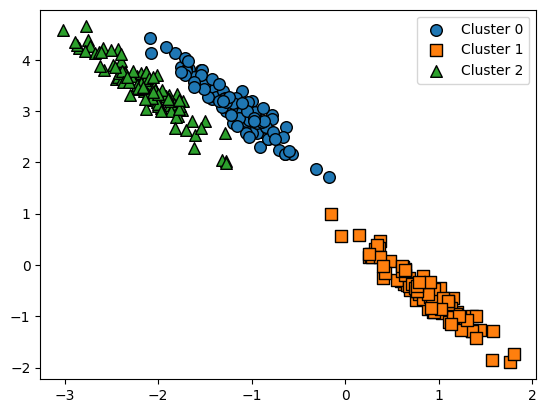

In [28]:
visualize_cluster_plot(None, cluster_df, 'target', iscenter=False)

In [29]:
# 3개의 cluster 기반 kmeans
kmeans= KMeans(3, random_state=0)
kmeans_label = kmeans.fit_predict(X_aniso)
cluster_df['kmeans_label'] = kmeans_label

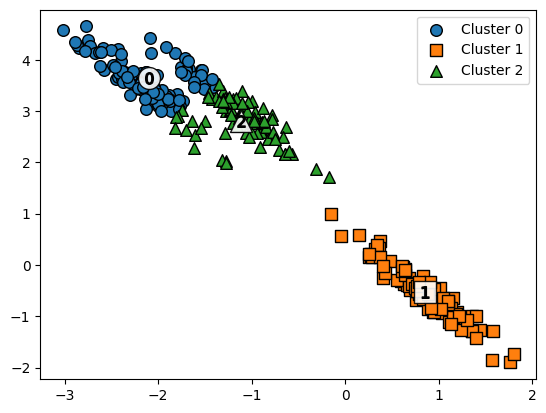

In [30]:
visualize_cluster_plot(kmeans, cluster_df, 'kmeans_label', iscenter=True)

In [31]:
# 3개의 cluster 기반 gmm
gmm = GaussianMixture(n_components=3, random_state=0)
gmm = gmm.fit(X_aniso)

In [32]:
gmm_label = gmm.predict(X_aniso)

In [33]:
cluster_df['gmm_label'] = gmm_label

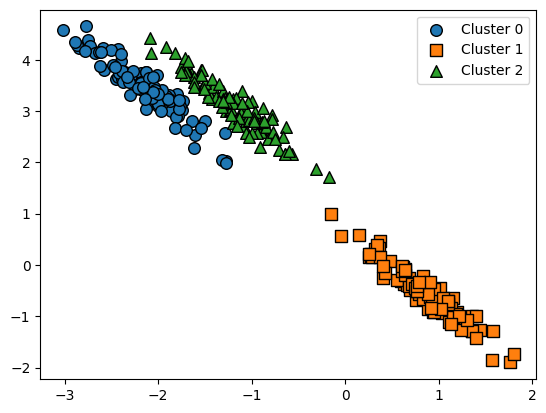

In [34]:
# 시각화
visualize_cluster_plot(gmm, cluster_df, 'gmm_label', iscenter=False)

In [35]:
print(cluster_df.groupby('target')['kmeans_label'].value_counts())
print(cluster_df.groupby('target')['gmm_label'].value_counts())

target  kmeans_label
0       2                73
        0                27
1       1               100
2       0                86
        2                14
Name: count, dtype: int64
target  gmm_label
0       2            100
1       1            100
2       0            100
Name: count, dtype: int64
